## Import

In [1]:
import os, sys

# 実行環境に応じてプロジェクトルートを決めて移動する
try:
    # .py として実行された場合は __file__ からルートを解決
    PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    # ノートブック実行(__file__ が無い)
    if 'google.colab' in sys.modules:
        # Colab: Drive をマウントしてプロジェクトを配置した場所へ
        from google.colab import drive
        drive.mount('/content/drive')
        PROJECT_ROOT = '/content/drive/MyDrive/deep-learning-6'  # アップロード先に合わせる
    else:
        # ローカルの Jupyter/VSCode: codebot が見つかるまで親をたどる
        PROJECT_ROOT = os.getcwd()
        while not os.path.isdir(os.path.join(PROJECT_ROOT, 'codebot')):
            parent = os.path.dirname(PROJECT_ROOT)
            if parent == PROJECT_ROOT:
                raise RuntimeError('プロジェクトルート(codebotを含む)が見つかりません')
            PROJECT_ROOT = parent

os.chdir(PROJECT_ROOT)
sys.path.append(PROJECT_ROOT)

from itertools import cycle
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
from codebot.model import GPT
from codebot.utils import get_device

Mounted at /content/drive


## setting

In [2]:
device = get_device()
data_path = 'codebot/tiny_codes.bin'
tokenizer_path = 'codebot/merge_rules.pkl'
model_save_path = 'codebot/model_pretrain.pt'

## Hyper Parameters

In [3]:
context_len = 256
vocab_size = 1000
batch_size = 32
learning_rate = 3e-4
max_iters = 20000
embed_dim = 384
n_head = 6
n_layer = 6
ff_dim = 4 * embed_dim
dropout_rate = 0.1

## Dataset Class

In [4]:
class TokenDataset(Dataset):
    def __init__(self, tokens, context_len):
        self.tokens = torch.tensor(tokens, dtype=torch.long)
        self.context_len = context_len

    def __len__(self):
        return len(self.tokens) - self.context_len

    def __getitem__(self, idx):
        x = self.tokens[idx:idx+self.context_len]
        y = self.tokens[idx+1:idx+self.context_len+1]
        return x, y

## データ準備

In [5]:
ids = np.fromfile(data_path, dtype=np.uint16)
dataset = TokenDataset(ids, context_len)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

## model, optimizer

In [6]:
model = GPT(
    vocab_size=vocab_size,
    max_context_len=context_len,
    embed_dim=embed_dim,
    n_head=n_head,
    n_layer=n_layer,
    ff_dim=ff_dim,
    dropout_rate=dropout_rate
).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

total_params = sum(p.numel() for p in model.parameters())
print(f"パラメータ数: {total_params:,} ({total_params/1e6:.1f}M)")

losses = []
data_iter = cycle(dataloader)  # 無限ループ化
pbar = tqdm(range(max_iters))

for i in pbar:
    batch_x, batch_y = next(data_iter)
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)

    logits = model(batch_x)
    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), batch_y.view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    pbar.set_postfix({'loss': f'{loss.item():.4f}'})

パラメータ数: 11,121,640 (11.1M)


100%|██████████| 20000/20000 [21:16<00:00, 15.67it/s, loss=0.6728]


## Save data

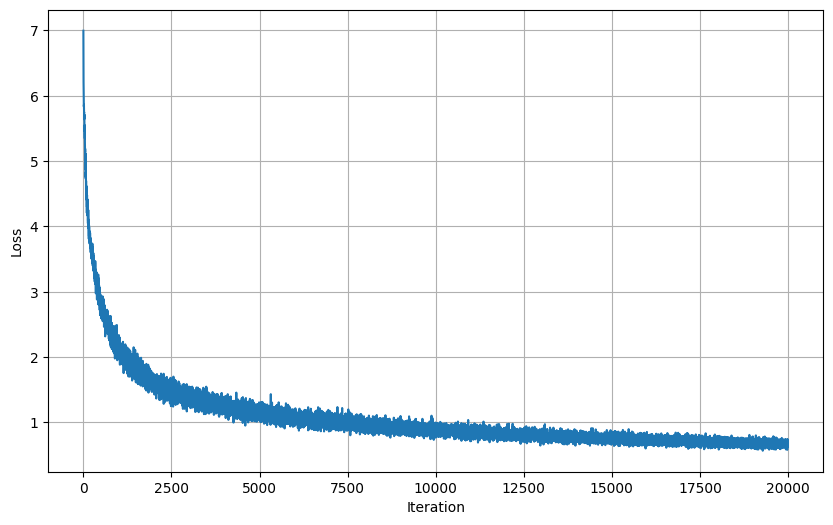

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig('loss_pretrain.png')

model.save(model_save_path)